## Calibration based on Beta calibration with raw probabilities

In [14]:
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from typing import Optional

sys.path.append("../../../services/")
from index import Index, IndexDataset
from process_funcs import retrieve_answer_token_index
from metric_funcs import calculate_ece_adaptive_bins

## Environment preparation

In [15]:
HPARAMETER_SEARCH_TRIALS = 15

torch.random.manual_seed(42)

In [16]:
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"Index {i}: {props.name}, UUID: {props.uuid}")

Index 0: NVIDIA L40, UUID: 441e6008-cd27-34b5-c81a-17dad9d4a894
Index 1: NVIDIA L40S, UUID: c15d4e7a-29b2-896a-f7bf-3d1a528040a5
Index 2: NVIDIA L40, UUID: 31a471eb-a3b0-032b-8b74-9bd805c42af3
Index 3: NVIDIA L40, UUID: 7b7e27a5-a434-d736-eabd-b9414645af76
Index 4: NVIDIA L40S, UUID: d5913034-d8e8-b46e-940e-7df6d85d3884
Index 5: NVIDIA H100 NVL, UUID: d4d3fa02-fdea-80f5-9082-0157b1423027
Index 6: NVIDIA H100 PCIe, UUID: 1ea36751-5cc4-4522-aa5e-55350c485c0c


In [17]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)

cuda:3


## Core functions

In [18]:
# Module which will learn parameters for llm beta calibration

class BetaCalibration(nn.Module):
    def __init__(self, device=device):
        super().__init__()
        self.log_a = nn.Parameter(torch.tensor(0.0, device=device))
        self.log_b = nn.Parameter(torch.tensor(0.0, device=device))
        self.c = nn.Parameter(torch.tensor(0.0, device=device))
        self.eps = 1e-6

    def forward(self, probs):
        probs = torch.clamp(probs, self.eps, 1 - self.eps)

        a = torch.exp(self.log_a)
        b = torch.exp(self.log_b)
        calibrated_probs = torch.sigmoid(
            self.c + a * torch.log(probs) - b * torch.log(1 - probs)
        )
        return calibrated_probs

    def calibrate(self, probs):
        self.eval()
        with torch.no_grad():
            return self.forward(probs).cpu()

In [19]:
# Function to fit the calibration model

def fit_calibration_model(
    model: nn.Module,
    train_data: IndexDataset,
    test_data: Optional[IndexDataset] = None,
    lr_max=1e-2,
    lr_min=1e-4,
    batch_size=64,
    epochs=3,
    plot_interval=3,
    verbose=True
):
    optimizer = torch.optim.Adam(model.parameters(), lr_max)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, epochs * (len(train_data) / batch_size), lr_min
    )

    train_losses = []
    test_losses = []
    iterations = []

    iteration_counter = 0

    for _ in range(epochs):
        for start in range(0, len(train_data) - batch_size, batch_size):
            train_batch = train_data.get(start, start + batch_size)
            if not train_batch:
                continue

            optimizer.zero_grad()
            
            train_batch_confidence = train_batch["confidence"].to(device=device, dtype=torch.float32)
            train_batch_labels = train_batch["labels"].to(device=device, dtype=torch.float32)
            
            train_cal_scores = model(train_batch_confidence)

            train_loss = torch.nn.functional.binary_cross_entropy(
                train_cal_scores,
                train_batch_labels
            )

            train_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            if (
                test_data is not None
                and iteration_counter % plot_interval == 0
            ):
                train_loss = train_loss.item()
                train_losses.append(train_loss)

                test_batch = test_data.get(0, min(batch_size, len(test_data)))
                if test_batch:
                    test_batch_confidence = test_batch["confidence"].to(device=device, dtype=torch.float32)
                    test_batch_labels = test_batch["labels"].to(device=device, dtype=torch.float32)
                    
                    with torch.no_grad():
                        test_cal_scores = model(test_batch_confidence)
                        test_loss = torch.nn.functional.binary_cross_entropy(
                            test_cal_scores,
                            test_batch_labels
                        )
                        test_losses.append(test_loss.item())
                    
                    iterations.append(iteration_counter)
            iteration_counter += 1

    if len(iterations) > 0 and verbose:
        plt.figure(figsize=(4, 4))
        plt.plot(iterations, train_losses, label="Train Loss", marker="o")
        if len(test_losses) > 0:
            plt.plot(iterations, test_losses, label="Test Loss", marker="s")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss over Iterations")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return model

In [20]:
# Function to find the best hyperparameters for calibration model

def fit_hparameters(
    train_data: IndexDataset,
    test_data: IndexDataset,
    verbose=False
    ):
    results = []
    for _ in tqdm(range(HPARAMETER_SEARCH_TRIALS)):
        lr_max = np.random.choice([1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
        lr_min = np.random.choice([1e-3, 1e-4, 5e-5, 1e-5, 5e-6, 1e-6])
        batch_size = 16
        epochs = np.random.choice([3, 5, 10])

        model = fit_calibration_model(
            BetaCalibration(),
            train_data=train_data,
            test_data=test_data,
            lr_max=lr_max,
            lr_min=lr_min,
            batch_size=batch_size,
            epochs=epochs,
            verbose=verbose
        )
        
        val_calibrated_probs = model.calibrate(test_data.get()["confidence"])    
        ece = calculate_ece_adaptive_bins(
            val_calibrated_probs,
            test_data.get()["labels"],
            verbose=verbose,
            device=device 
        )
        
        print(f"Current ECE: {ece}")
        results.append(
            {
                "hparameters": {
                    "lr_max": lr_max,
                    "lr_min": lr_min,
                    "batch_size": batch_size,
                    "epochs": epochs,
                },
                "parameters": model.state_dict(),
                "ece": ece,
            }
        )

    return min(results, key=lambda x: x["ece"])

In [21]:
# Function to test calibration model

def test_calibration_model(
    model: nn.Module,
    X_test: torch.Tensor,
    y_test: torch.Tensor
):
    not_calibrated_test_answers_probs = X_test
    calibrated_test_answers_probs = model.calibrate(
        X_test
    )
    
    print(
        f"ECE on NON calibrated answer (test data): {
            calculate_ece_adaptive_bins(
            not_calibrated_test_answers_probs,
            y_test,
            verbose=True,
            device=device
            )
        }"
    )

    print(
        f"ECE on calibrated answer (test data): {
            calculate_ece_adaptive_bins(
            calibrated_test_answers_probs,
            y_test,
            verbose=True,
            device=device
            )
        }"
    )
    
    accuracies = (
        y_test
    ).to(torch.float)
    print(f"Accuracy on answer from test: {torch.mean(accuracies).item()}")

## Index preparation 

In [22]:
index = Index("../../../index_data/mistral0.3_RACE_attn_cropped_12000")

In [23]:
# Function to process data for training phase

def process_elements_main(index_data: np.array):
    processed = {}

    # Getting labels of if the answer is correct or not 
    labels = torch.zeros(len(index_data), device=device, dtype=torch.long)
    for i, elem in enumerate(index_data):
        answer_token_index = retrieve_answer_token_index(elem["score_data"])
        labels[i] = (elem["score_data"][answer_token_index]["token"] == str(ord(elem["dataset_elem"]["answer"]) - ord('A')))
    processed["labels"] = labels
        
    # Getting probability scores of the answer token 
    # from the last layer of the LLM
    processed["confidence"] = torch.stack(
        [
            torch.tensor(
                x
                ["score_data"]
                [retrieve_answer_token_index(x["score_data"])]
                ["prob"]
            )
            for x in index_data
        ]
    ).clamp(1e-8).to(dtype=torch.float32, device=device)
    
    return processed

## Calibration

### Data preparing 

In [24]:
train = IndexDataset(
    index, process_elements_main, split="train", load_all_data=True
)
val = IndexDataset(
    index, process_elements_main, split="val", load_all_data=True
)
test = IndexDataset(
    index, process_elements_main, split="test", load_all_data=True
)

IndexError: list index out of range

### Training model and finding best hparameters

  0%|          | 0/15 [00:00<?, ?it/s]

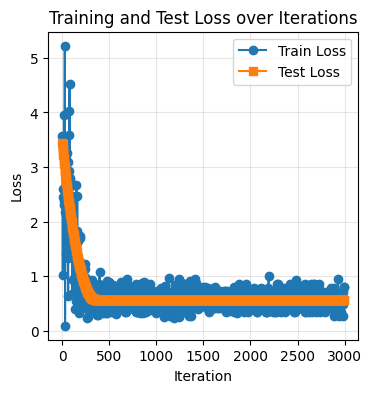

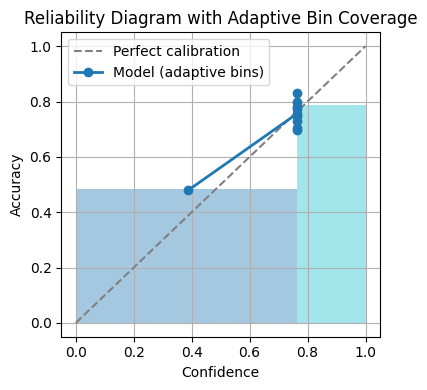

  7%|▋         | 1/15 [00:08<01:52,  8.01s/it]

Current ECE: 0.0399615541100502


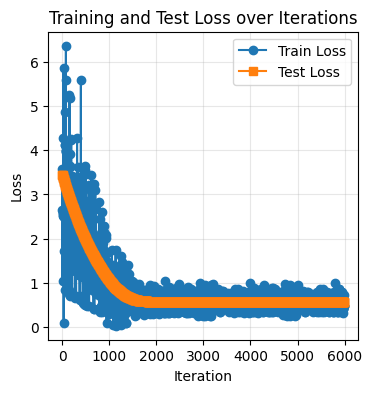

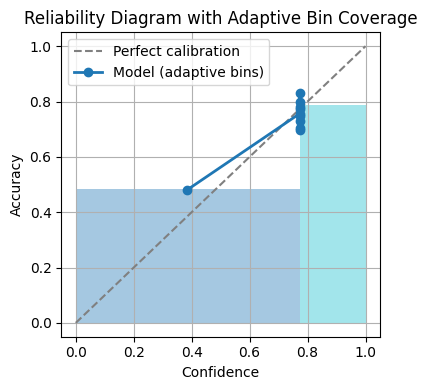

 13%|█▎        | 2/15 [00:20<02:20, 10.82s/it]

Current ECE: 0.04129239171743393


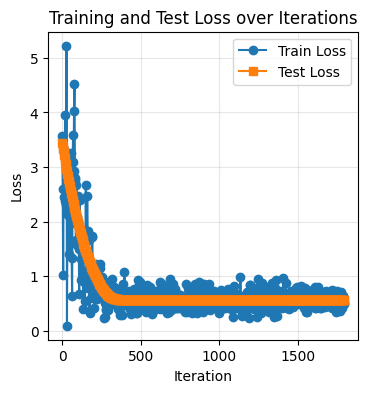

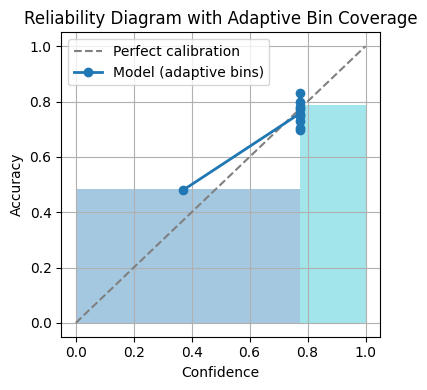

 20%|██        | 3/15 [00:24<01:32,  7.70s/it]

Current ECE: 0.04256276413798332


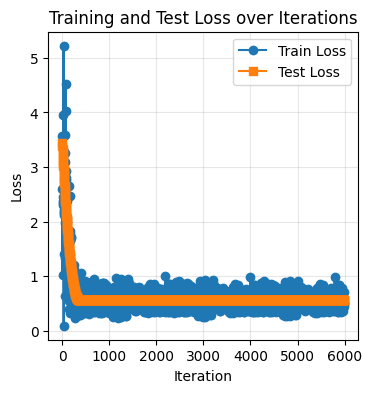

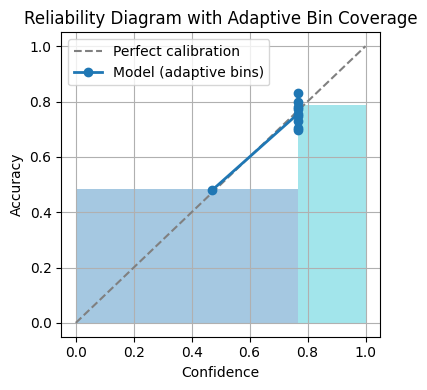

 27%|██▋       | 4/15 [00:36<01:43,  9.45s/it]

Current ECE: 0.03214561194181442


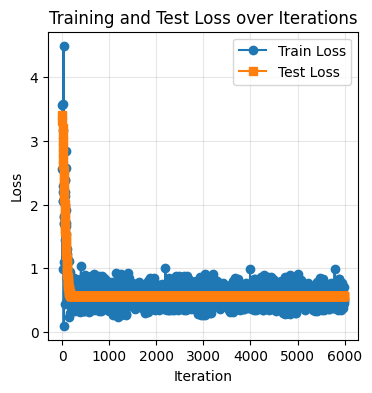

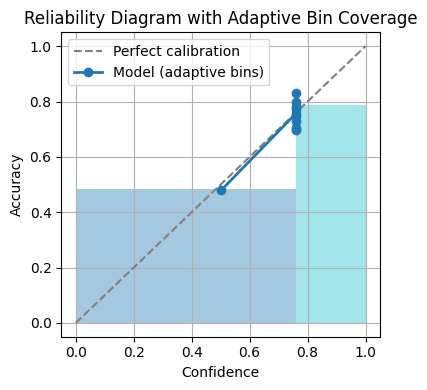

 33%|███▎      | 5/15 [00:49<01:44, 10.48s/it]

Current ECE: 0.03271818161010742


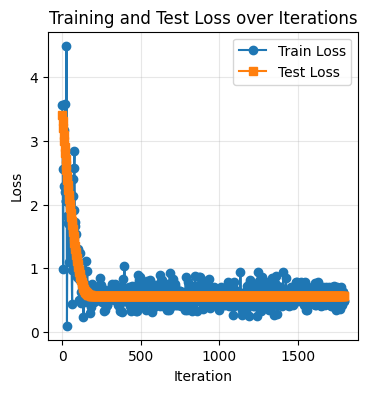

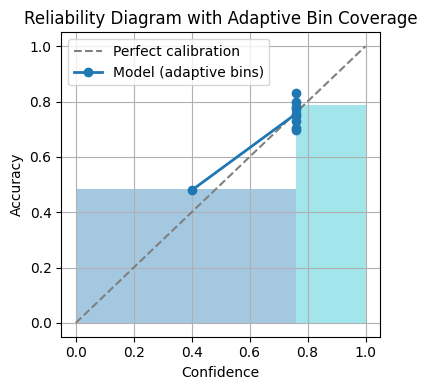

 40%|████      | 6/15 [00:52<01:12,  8.05s/it]

Current ECE: 0.03846219182014465


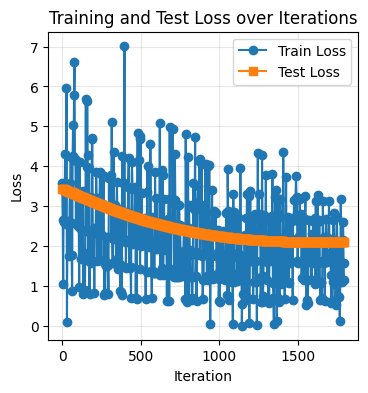

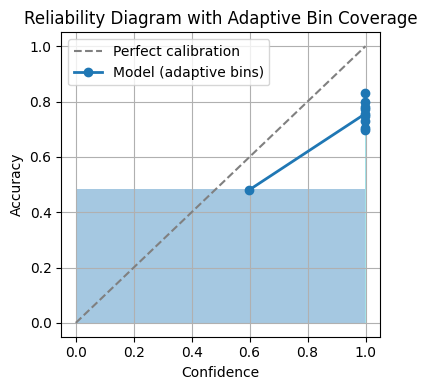

 47%|████▋     | 7/15 [00:55<00:51,  6.47s/it]

Current ECE: 0.2291261851787567


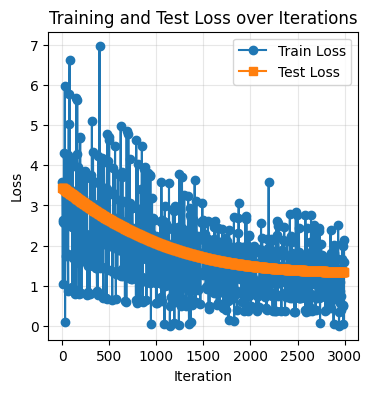

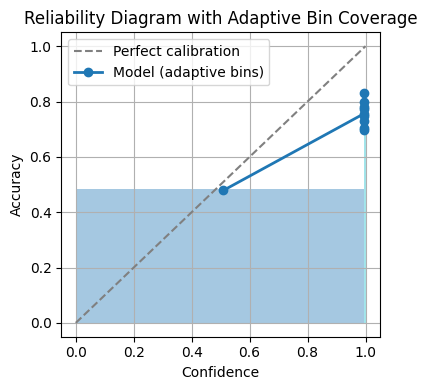

 53%|█████▎    | 8/15 [01:02<00:46,  6.57s/it]

Current ECE: 0.2163458615541458


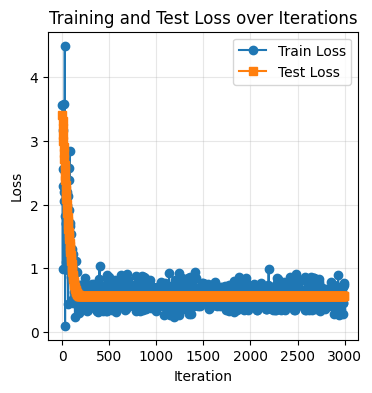

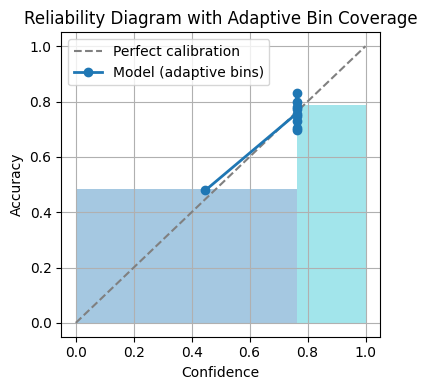

 60%|██████    | 9/15 [01:09<00:40,  6.74s/it]

Current ECE: 0.033856309950351715


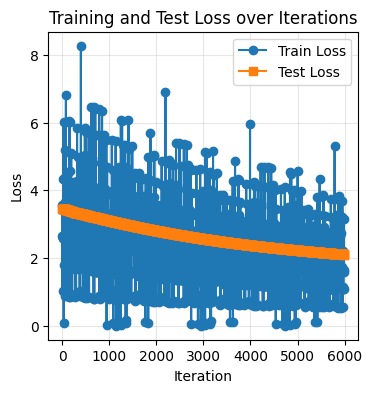

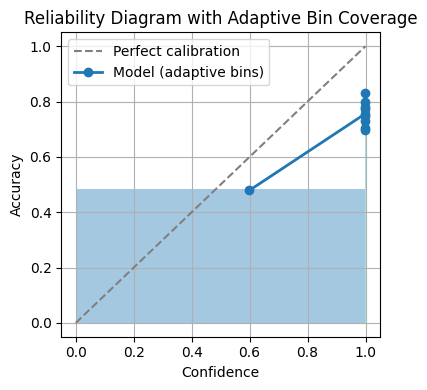

 67%|██████▋   | 10/15 [01:22<00:43,  8.60s/it]

Current ECE: 0.22943589091300964


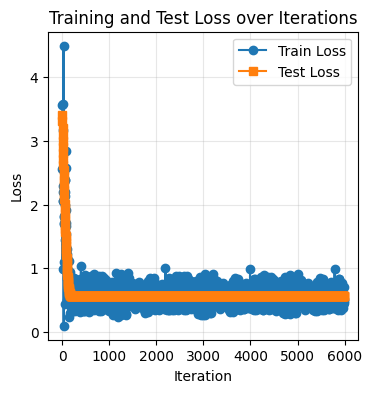

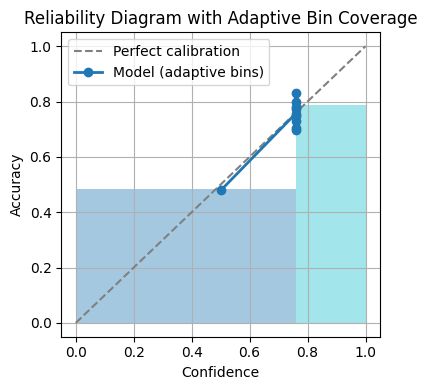

 73%|███████▎  | 11/15 [01:35<00:39,  9.88s/it]

Current ECE: 0.032595571130514145


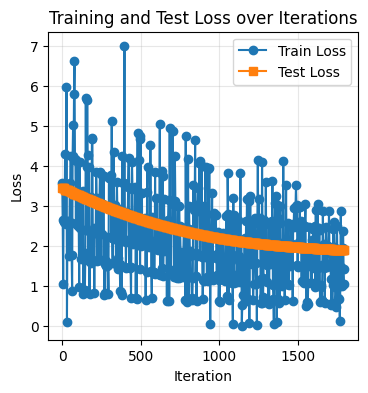

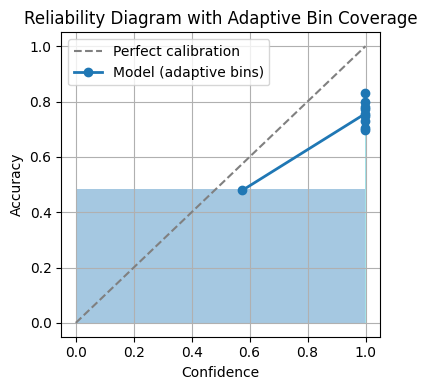

 80%|████████  | 12/15 [01:39<00:24,  8.24s/it]

Current ECE: 0.2267240583896637


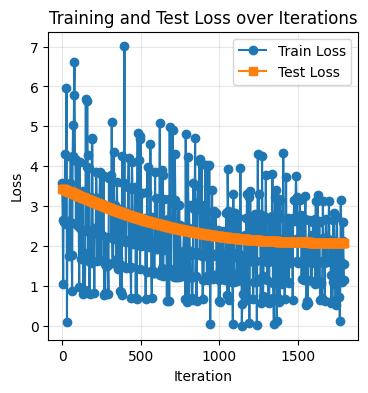

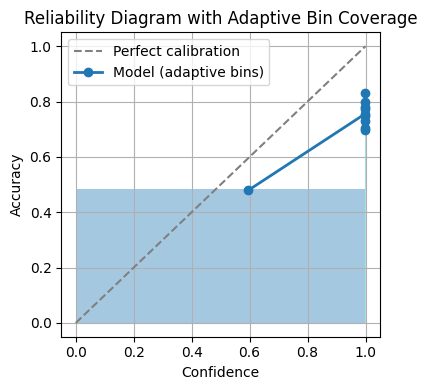

 87%|████████▋ | 13/15 [01:43<00:13,  6.97s/it]

Current ECE: 0.2290021926164627


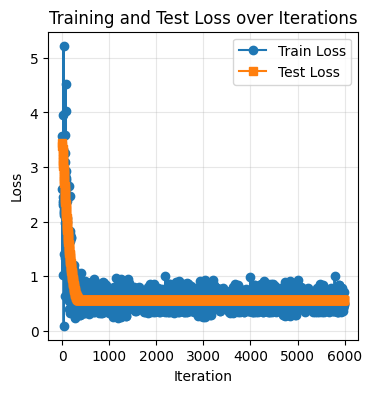

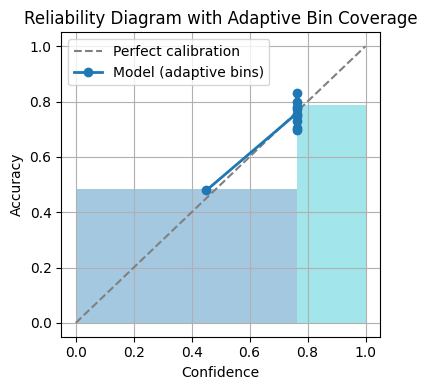

 93%|█████████▎| 14/15 [01:57<00:09,  9.05s/it]

Current ECE: 0.033494558185338974


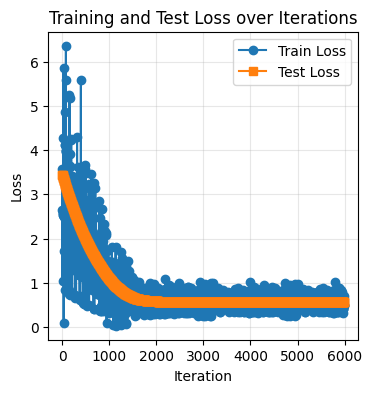

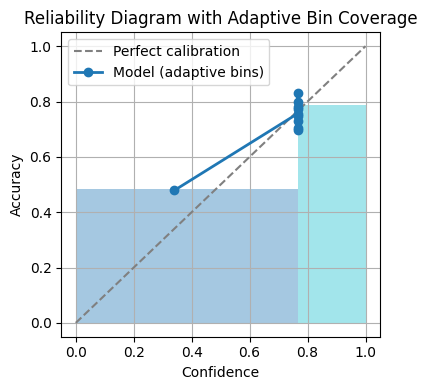

100%|██████████| 15/15 [02:11<00:00,  8.79s/it]

Current ECE: 0.04478423297405243


In [ ]:
fit_results = fit_hparameters(
    train_data=train,
    test_data=val,
    verbose=True
)

### Testing model

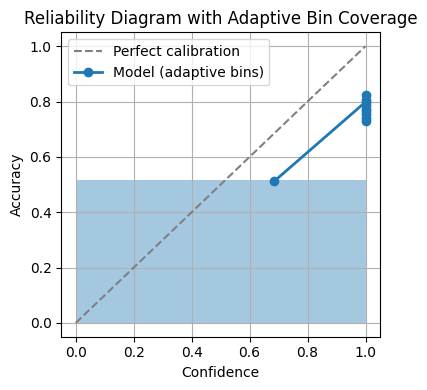

ECE on NON calibrated answer (test data): 0.21901674568653107


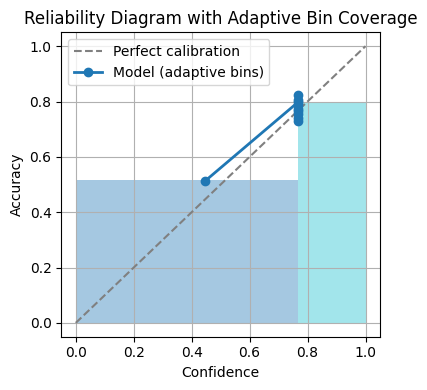

ECE on calibrated answer (test data): 0.02970157563686371
Accuracy on answer from test: 0.7497915029525757


In [ ]:
model = BetaCalibration()
model.load_state_dict(fit_results["parameters"])
model.eval()
    
test_calibration_model(
    model,
    test.get()["confidence"],
    test.get()["labels"],
)